## Header

Этот датасет — знаменитый **Ames Housing Dataset**. В нем собрана подробная информация о продаже жилой недвижимости в городе Эймс (штат Айова, США) за период с 2006 по 2010 год.

Содержание можно разделить на четыре основных блока:

1. **Физические характеристики:** Общая площадь, количество комнат, тип фундамента, материал кровли и стен.
2. **Качество и состояние:** Субъективные и объективные оценки отделки дома, кухни, подвала и гаража.
3. **Локация и земля:** Район города, близость к железным дорогам или паркам, уклон участка и наличие коммуникаций.
4. **История продаж:** Цена сделки (`SalePrice` — наш таргет), дата продажи, тип контракта (например, покупка в ипотеку или сделка между родственниками).

Это классический пример «грязных» данных, где много категориальных переменных и пропусков, требующих вдумчивой предобработки.

In [45]:
import pandas as pd

In [3]:
df = pd.read_csv("house-prices-advanced-regression-techniques/train.csv")
df.head()
df.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [4]:
df.describe()
df.describe(include="object")

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,...,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,...,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,...,870,605,1311,1326,1340,3,157,49,1267,1198


In [5]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [6]:
df.dropna()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice


In [7]:
df_median = df.fillna(df.median)
df_mean = df.fillna(df.mean)
df_mode = df.fillna(df.mode)

df_median.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,<bound method DataFrame.median of Id ...,Reg,Lvl,AllPub,...,0,<bound method DataFrame.median of Id ...,<bound method DataFrame.median of Id ...,<bound method DataFrame.median of Id ...,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,<bound method DataFrame.median of Id ...,Reg,Lvl,AllPub,...,0,<bound method DataFrame.median of Id ...,<bound method DataFrame.median of Id ...,<bound method DataFrame.median of Id ...,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,<bound method DataFrame.median of Id ...,IR1,Lvl,AllPub,...,0,<bound method DataFrame.median of Id ...,<bound method DataFrame.median of Id ...,<bound method DataFrame.median of Id ...,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,<bound method DataFrame.median of Id ...,IR1,Lvl,AllPub,...,0,<bound method DataFrame.median of Id ...,<bound method DataFrame.median of Id ...,<bound method DataFrame.median of Id ...,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,<bound method DataFrame.median of Id ...,IR1,Lvl,AllPub,...,0,<bound method DataFrame.median of Id ...,<bound method DataFrame.median of Id ...,<bound method DataFrame.median of Id ...,0,12,2008,WD,Normal,250000


In [8]:
df_mean.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,<bound method DataFrame.mean of Id MS...,Reg,Lvl,AllPub,...,0,<bound method DataFrame.mean of Id MS...,<bound method DataFrame.mean of Id MS...,<bound method DataFrame.mean of Id MS...,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,<bound method DataFrame.mean of Id MS...,Reg,Lvl,AllPub,...,0,<bound method DataFrame.mean of Id MS...,<bound method DataFrame.mean of Id MS...,<bound method DataFrame.mean of Id MS...,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,<bound method DataFrame.mean of Id MS...,IR1,Lvl,AllPub,...,0,<bound method DataFrame.mean of Id MS...,<bound method DataFrame.mean of Id MS...,<bound method DataFrame.mean of Id MS...,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,<bound method DataFrame.mean of Id MS...,IR1,Lvl,AllPub,...,0,<bound method DataFrame.mean of Id MS...,<bound method DataFrame.mean of Id MS...,<bound method DataFrame.mean of Id MS...,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,<bound method DataFrame.mean of Id MS...,IR1,Lvl,AllPub,...,0,<bound method DataFrame.mean of Id MS...,<bound method DataFrame.mean of Id MS...,<bound method DataFrame.mean of Id MS...,0,12,2008,WD,Normal,250000


In [9]:
df_mode.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,<bound method DataFrame.mode of Id MS...,Reg,Lvl,AllPub,...,0,<bound method DataFrame.mode of Id MS...,<bound method DataFrame.mode of Id MS...,<bound method DataFrame.mode of Id MS...,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,<bound method DataFrame.mode of Id MS...,Reg,Lvl,AllPub,...,0,<bound method DataFrame.mode of Id MS...,<bound method DataFrame.mode of Id MS...,<bound method DataFrame.mode of Id MS...,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,<bound method DataFrame.mode of Id MS...,IR1,Lvl,AllPub,...,0,<bound method DataFrame.mode of Id MS...,<bound method DataFrame.mode of Id MS...,<bound method DataFrame.mode of Id MS...,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,<bound method DataFrame.mode of Id MS...,IR1,Lvl,AllPub,...,0,<bound method DataFrame.mode of Id MS...,<bound method DataFrame.mode of Id MS...,<bound method DataFrame.mode of Id MS...,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,<bound method DataFrame.mode of Id MS...,IR1,Lvl,AllPub,...,0,<bound method DataFrame.mode of Id MS...,<bound method DataFrame.mode of Id MS...,<bound method DataFrame.mode of Id MS...,0,12,2008,WD,Normal,250000


In [10]:
numeric_df = df.select_dtypes(include=['number'])
numeric_df = numeric_df.drop(columns='Id')
numeric_df.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,0,61,0,0,0,0,0,2,2008,208500
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,298,0,0,0,0,0,0,5,2007,181500
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,0,42,0,0,0,0,0,9,2008,223500
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,0,35,272,0,0,0,0,2,2006,140000
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,192,84,0,0,0,0,0,12,2008,250000


In [11]:
numeric_df.mean()

MSSubClass           56.897260
LotFrontage          70.049958
LotArea           10516.828082
OverallQual           6.099315
OverallCond           5.575342
YearBuilt          1971.267808
YearRemodAdd       1984.865753
MasVnrArea          103.685262
BsmtFinSF1          443.639726
BsmtFinSF2           46.549315
BsmtUnfSF           567.240411
TotalBsmtSF        1057.429452
1stFlrSF           1162.626712
2ndFlrSF            346.992466
LowQualFinSF          5.844521
GrLivArea          1515.463699
BsmtFullBath          0.425342
BsmtHalfBath          0.057534
FullBath              1.565068
HalfBath              0.382877
BedroomAbvGr          2.866438
KitchenAbvGr          1.046575
TotRmsAbvGrd          6.517808
Fireplaces            0.613014
GarageYrBlt        1978.506164
GarageCars            1.767123
GarageArea          472.980137
WoodDeckSF           94.244521
OpenPorchSF          46.660274
EnclosedPorch        21.954110
3SsnPorch             3.409589
ScreenPorch          15.060959
PoolArea

In [12]:
numeric_df.median()

MSSubClass           50.0
LotFrontage          69.0
LotArea            9478.5
OverallQual           6.0
OverallCond           5.0
YearBuilt          1973.0
YearRemodAdd       1994.0
MasVnrArea            0.0
BsmtFinSF1          383.5
BsmtFinSF2            0.0
BsmtUnfSF           477.5
TotalBsmtSF         991.5
1stFlrSF           1087.0
2ndFlrSF              0.0
LowQualFinSF          0.0
GrLivArea          1464.0
BsmtFullBath          0.0
BsmtHalfBath          0.0
FullBath              2.0
HalfBath              0.0
BedroomAbvGr          3.0
KitchenAbvGr          1.0
TotRmsAbvGrd          6.0
Fireplaces            1.0
GarageYrBlt        1980.0
GarageCars            2.0
GarageArea          480.0
WoodDeckSF            0.0
OpenPorchSF          25.0
EnclosedPorch         0.0
3SsnPorch             0.0
ScreenPorch           0.0
PoolArea              0.0
MiscVal               0.0
MoSold                6.0
YrSold             2008.0
SalePrice        163000.0
dtype: float64

In [13]:
numeric_df.mode()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,20,60.0,7200,5,5,2006,1950,0.0,0,0,...,0,0,0,0,0,0,0,6,2009,140000


In [14]:
numeric_df.min()

MSSubClass          20.0
LotFrontage         21.0
LotArea           1300.0
OverallQual          1.0
OverallCond          1.0
YearBuilt         1872.0
YearRemodAdd      1950.0
MasVnrArea           0.0
BsmtFinSF1           0.0
BsmtFinSF2           0.0
BsmtUnfSF            0.0
TotalBsmtSF          0.0
1stFlrSF           334.0
2ndFlrSF             0.0
LowQualFinSF         0.0
GrLivArea          334.0
BsmtFullBath         0.0
BsmtHalfBath         0.0
FullBath             0.0
HalfBath             0.0
BedroomAbvGr         0.0
KitchenAbvGr         0.0
TotRmsAbvGrd         2.0
Fireplaces           0.0
GarageYrBlt       1900.0
GarageCars           0.0
GarageArea           0.0
WoodDeckSF           0.0
OpenPorchSF          0.0
EnclosedPorch        0.0
3SsnPorch            0.0
ScreenPorch          0.0
PoolArea             0.0
MiscVal              0.0
MoSold               1.0
YrSold            2006.0
SalePrice        34900.0
dtype: float64

In [15]:
numeric_df.max()

MSSubClass          190.0
LotFrontage         313.0
LotArea          215245.0
OverallQual          10.0
OverallCond           9.0
YearBuilt          2010.0
YearRemodAdd       2010.0
MasVnrArea         1600.0
BsmtFinSF1         5644.0
BsmtFinSF2         1474.0
BsmtUnfSF          2336.0
TotalBsmtSF        6110.0
1stFlrSF           4692.0
2ndFlrSF           2065.0
LowQualFinSF        572.0
GrLivArea          5642.0
BsmtFullBath          3.0
BsmtHalfBath          2.0
FullBath              3.0
HalfBath              2.0
BedroomAbvGr          8.0
KitchenAbvGr          3.0
TotRmsAbvGrd         14.0
Fireplaces            3.0
GarageYrBlt        2010.0
GarageCars            4.0
GarageArea         1418.0
WoodDeckSF          857.0
OpenPorchSF         547.0
EnclosedPorch       552.0
3SsnPorch           508.0
ScreenPorch         480.0
PoolArea            738.0
MiscVal           15500.0
MoSold               12.0
YrSold             2010.0
SalePrice        755000.0
dtype: float64

In [16]:
numeric_df.var()

MSSubClass       1.789338e+03
LotFrontage      5.897492e+02
LotArea          9.962565e+07
OverallQual      1.912679e+00
OverallCond      1.238322e+00
YearBuilt        9.122154e+02
YearRemodAdd     4.262328e+02
MasVnrArea       3.278497e+04
BsmtFinSF1       2.080255e+05
BsmtFinSF2       2.602391e+04
BsmtUnfSF        1.952464e+05
TotalBsmtSF      1.924624e+05
1stFlrSF         1.494501e+05
2ndFlrSF         1.905571e+05
LowQualFinSF     2.364204e+03
GrLivArea        2.761296e+05
BsmtFullBath     2.692682e-01
BsmtHalfBath     5.700283e-02
FullBath         3.035082e-01
HalfBath         2.528937e-01
BedroomAbvGr     6.654938e-01
KitchenAbvGr     4.854892e-02
TotRmsAbvGrd     2.641903e+00
Fireplaces       4.155947e-01
GarageYrBlt      6.095825e+02
GarageCars       5.584797e-01
GarageArea       4.571251e+04
WoodDeckSF       1.570981e+04
OpenPorchSF      4.389861e+03
EnclosedPorch    3.735550e+03
3SsnPorch        8.595059e+02
ScreenPorch      3.108889e+03
PoolArea         1.614216e+03
MiscVal   

In [17]:
numeric_df.skew()

MSSubClass        1.407657
LotFrontage       2.163569
LotArea          12.207688
OverallQual       0.216944
OverallCond       0.693067
YearBuilt        -0.613461
YearRemodAdd     -0.503562
MasVnrArea        2.669084
BsmtFinSF1        1.685503
BsmtFinSF2        4.255261
BsmtUnfSF         0.920268
TotalBsmtSF       1.524255
1stFlrSF          1.376757
2ndFlrSF          0.813030
LowQualFinSF      9.011341
GrLivArea         1.366560
BsmtFullBath      0.596067
BsmtHalfBath      4.103403
FullBath          0.036562
HalfBath          0.675897
BedroomAbvGr      0.211790
KitchenAbvGr      4.488397
TotRmsAbvGrd      0.676341
Fireplaces        0.649565
GarageYrBlt      -0.649415
GarageCars       -0.342549
GarageArea        0.179981
WoodDeckSF        1.541376
OpenPorchSF       2.364342
EnclosedPorch     3.089872
3SsnPorch        10.304342
ScreenPorch       4.122214
PoolArea         14.828374
MiscVal          24.476794
MoSold            0.212053
YrSold            0.096269
SalePrice         1.882876
d

In [18]:
numeric_df.kurt()

MSSubClass         1.580188
LotFrontage       17.452867
LotArea          203.243271
OverallQual        0.096293
OverallCond        1.106413
YearBuilt         -0.439552
YearRemodAdd      -1.272245
MasVnrArea        10.082417
BsmtFinSF1        11.118236
BsmtFinSF2        20.113338
BsmtUnfSF          0.474994
TotalBsmtSF       13.250483
1stFlrSF           5.745841
2ndFlrSF          -0.553464
LowQualFinSF      83.234817
GrLivArea          4.895121
BsmtFullBath      -0.839098
BsmtHalfBath      16.396642
FullBath          -0.857043
HalfBath          -1.076927
BedroomAbvGr       2.230875
KitchenAbvGr      21.532404
TotRmsAbvGrd       0.880762
Fireplaces        -0.217237
GarageYrBlt       -0.418341
GarageCars         0.220998
GarageArea         0.917067
WoodDeckSF         2.992951
OpenPorchSF        8.490336
EnclosedPorch     10.430766
3SsnPorch        123.662379
ScreenPorch       18.439068
PoolArea         223.268499
MiscVal          701.003342
MoSold            -0.404109
YrSold            -1

use onehot-encoder. Drop SaleType bc TargetEncoding will be used for it instead

In [ ]:
pd.get_dummies(df.drop('SaleType', axis=1))

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,MiscFeature_Gar2,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,False,False,False,False,False,False,False,False,True,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,False,False,False,False,False,False,False,False,True,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,False,False,False,False,False,False,False,False,True,False
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,False,False,False,False,True,False,False,False,False,False
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,62.0,7917,6,5,1999,2000,0.0,0,...,False,False,False,False,False,False,False,False,True,False
1456,1457,20,85.0,13175,6,6,1978,1988,119.0,790,...,False,False,False,False,False,False,False,False,True,False
1457,1458,70,66.0,9042,7,9,1941,2006,0.0,275,...,False,False,True,False,False,False,False,False,True,False
1458,1459,20,68.0,9717,5,6,1950,1996,0.0,49,...,False,False,False,False,False,False,False,False,True,False


LabelEncoding for `SaleType`

In [ ]:
df['SaleType_Label'] = df['SaleType'].astype('category').cat.codes
print(df[['SaleType', 'SaleType_Label']].value_counts())

SaleType_Label
8    1267
6     122
0      43
3       9
4       5
5       5
1       4
7       3
2       2
Name: count, dtype: int64
SaleType  SaleType_Label
WD        8                 1267
New       6                  122
COD       0                   43
ConLD     3                    9
ConLI     4                    5
ConLw     5                    5
CWD       1                    4
Oth       7                    3
Con       2                    2
Name: count, dtype: int64


TargetEncoding for `Neighborhood`

In [35]:
df['Nighborhood_Target'] = df.groupby('Neighborhood')['SalePrice'].transform('mean')

print(df[['Neighborhood', 'SalePrice', 'Nighborhood_Target']].head(10))

  Neighborhood  SalePrice  Nighborhood_Target
0      CollgCr     208500       197965.773333
1      Veenker     181500       238772.727273
2      CollgCr     223500       197965.773333
3      Crawfor     140000       210624.725490
4      NoRidge     250000       335295.317073
5      Mitchel     143000       156270.122449
6      Somerst     307000       225379.837209
7       NWAmes     200000       189050.068493
8      OldTown     129900       128225.300885
9      BrkSide     118000       124834.051724


FeatureHashing for `Exterior1st`

In [37]:
# Define the number of features (buckets)
n_features = 6

# 1. Map string to a bucket index (0 to 3)
df['Hash_Index'] = df['Exterior1st'].apply(lambda x: hash(x) % n_features)

# 2. Pivot to create the feature columns
hashed_df = pd.get_dummies(df['Hash_Index'], prefix='Hash')
print(pd.concat([df['Exterior1st'], hashed_df], axis=1))

     Exterior1st  Hash_0  Hash_1  Hash_2  Hash_3  Hash_4  Hash_5
0        VinylSd   False   False   False   False    True   False
1        MetalSd   False   False   False   False    True   False
2        VinylSd   False   False   False   False    True   False
3        Wd Sdng   False   False    True   False   False   False
4        VinylSd   False   False   False   False    True   False
...          ...     ...     ...     ...     ...     ...     ...
1455     VinylSd   False   False   False   False    True   False
1456     Plywood   False    True   False   False   False   False
1457     CemntBd   False    True   False   False   False   False
1458     MetalSd   False   False   False   False    True   False
1459     HdBoard   False   False   False    True   False   False

[1460 rows x 7 columns]


Create a new column named `TotalSF` which contains total square footage of the house

In [38]:
# 1. Fill NaN values with 0 first to ensure the math works
# Some houses don't have basements, so TotalBsmtSF might be null
df['TotalBsmtSF'] = df['TotalBsmtSF'].fillna(0)

# 2. Create the TotalSF column
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

# 3. (Optional) Check your work
print(df[['TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'TotalSF']].head())

   TotalBsmtSF  1stFlrSF  2ndFlrSF  TotalSF
0          856       856       854     2566
1         1262      1262         0     2524
2          920       920       866     2706
3          756       961       756     2473
4         1145      1145      1053     3343


## Plots

- matplotlib
- seaborn
- plotly

In [43]:
# Imports
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

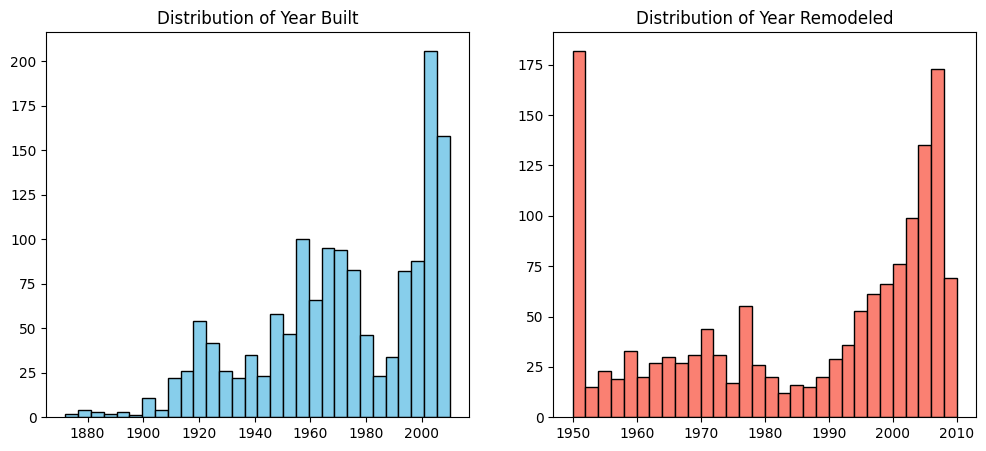

In [40]:
# matplotlib
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].hist(df['YearBuilt'], bins=30, color='skyblue', edgecolor='black')
ax[0].set_title('Distribution of Year Built')

ax[1].hist(df['YearRemodAdd'], bins=30, color='salmon', edgecolor='black')
ax[1].set_title('Distribution of Year Remodeled')

plt.show()

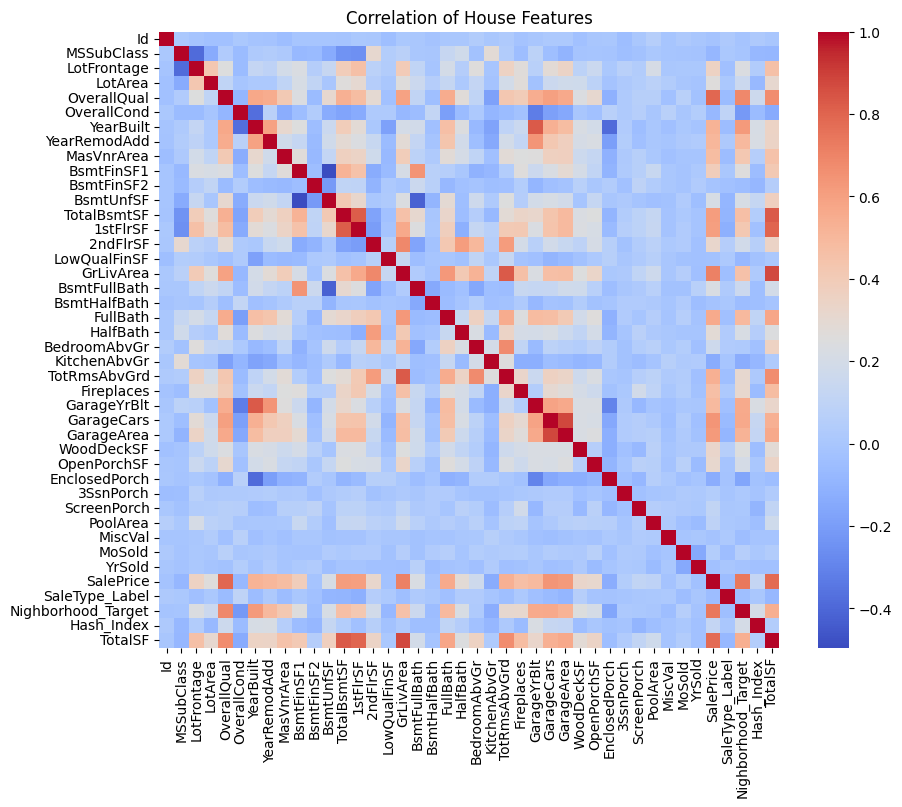

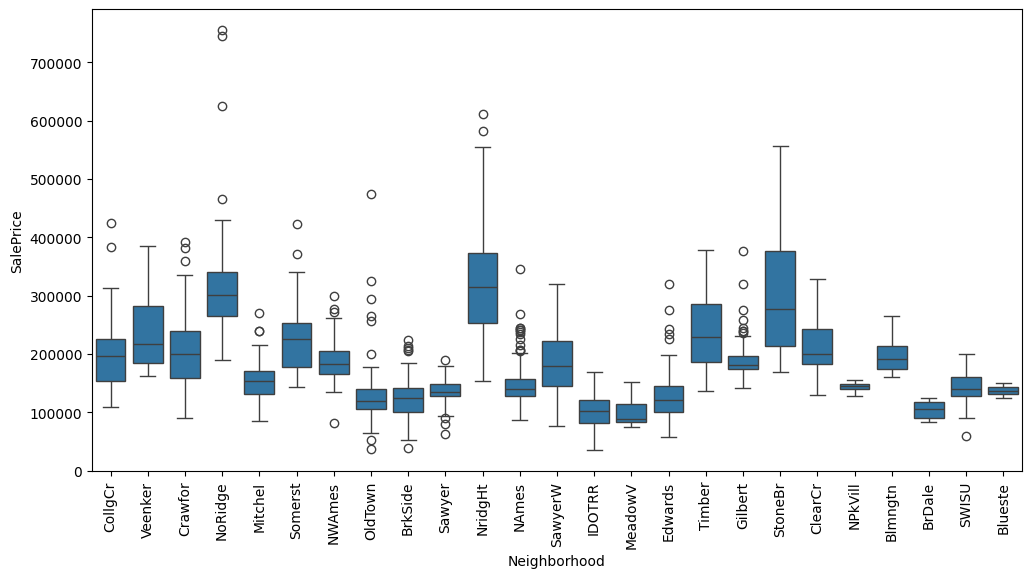

In [42]:
# Seaborn

# Heatmap to find the best predictors of SalePrice
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm')
plt.title('Correlation of House Features')
plt.show()

# Boxplot for Neighborhood vs Price
plt.figure(figsize=(12, 6))
sns.boxplot(x='Neighborhood', y='SalePrice', data=df)
plt.xticks(rotation=90)
plt.show()

In [44]:
# plotly

# Hover over points to see which specific neighborhood they belong to
fig = px.scatter(df, x="TotalSF", y="SalePrice", 
                 color="OverallQual", 
                 hover_data=['Neighborhood', 'YearBuilt'],
                 title="Total SF vs Sale Price (Hover for Details)")
fig.show()

## Conclusion


### Что я понял про датасет

1. **Размерность и сложность:** В данных более 70 признаков, что требует серьезного отбора (Feature Selection) — не все они одинаково полезны.
2. **Жилая площадь — это база:** Параметры `GrLivArea` и `TotalBsmtSF` являются главными числовыми предикторами цены.
3. **Качество важнее возраста:** `OverallQual` (субъективная оценка материала) часто сильнее коррелирует с ценой, чем фактический `YearBuilt`.
4. **Разнообразие типов данных:** Датасет — идеальный полигон для практики кодирования (есть порядковые, номинальные и числовые признаки).
5. **Проблема пропусков:** В колонках вроде `PoolQC`, `MiscFeature` и `Alley` пропуски (NA) — это не ошибка, а отдельная категория "Отсутствует".
6. **Нелинейность:** Влияние площади на цену не всегда линейно; огромные особняки могут стоить непропорционально дорого (или дешево, если они в плохом состоянии).
7. **Локация решает:** Переменная `Neighborhood` — самый важный категориальный признак, разделяющий дома на ценовые кластеры.
8. **Мультиколлинеарность:** Многие признаки дублируют друг друга (например, `GarageCars` и `GarageArea`). Нужно оставлять только один из них.

---

### Гипотезы и наблюдения

* **Гипотеза о "Золотом ремонте":** Дома с высоким `OverallCond`, но низким `YearBuilt` и недавним `YearRemodAdd`, могут стоить дороже новых домов среднего качества. Ремонт "омолаживает" цену сильнее, чем кажется.
* **Влияние зонирования:** Категория `RL` (Residential Low Density) должна иметь самые высокие цены из-за комфорта, в то время как `C` (Commercial) и `RM` будут содержать выбросы в нижнюю сторону.
* **Природа выбросов:** Скорее всего, в данных есть дома с огромной площадью (`GrLivArea` > 4000 кв. футов), которые продавались по аномально низким ценам (возможно, срочная продажа или разрушенное состояние). Их нужно удалять.
* **Сезонный фактор:** Месяц продажи (`MoSold`) может влиять на цену (весной/летом рынок активнее), но это влияние будет вторичным по сравнению с физическими характеристиками.

---

### Что делать дальше?

1. **Цель:** Предсказание `SalePrice` (задача регрессии).
2. **Модель:** Я бы начал с **XGBoost** или **LightGBM**. Эти модели на основе градиентного бустинга отлично справляются с табличными данными и "проглатывают" разные типы признаков без строгой нормализации.
3. **Препроцессинг:** * Логарифмирование таргета (`SalePrice`), чтобы сгладить перекос цен.
* Создание признака `TotalSF`.
* **Target Encoding** для районов (`Neighborhood`).



---

### Какие подсказки брал у AI и что дописывал руками

* **Что брал:** Объяснение разницы между кодировщиками (Label vs Target) и концепцию Feature Hashing. Получил готовую формулу для объединения площадей (`TotalSF`) и примеры кода на Pandas.
* **Что делал руками:** * Анализировал описание признаков (понимал, где `NA` — это категория, а где — реальный пропуск).
* Решал, какие именно колонки суммировать для `TotalSF` (база + 1 этаж + 2 этаж).
* Выбирал типы графиков: решил, что для выбросов лучше использовать Scatter Plot в Plotly, а для корреляций — Heatmap в Seaborn.